In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FILE_PATH = "C:/Users/Lyst/Desktop/New folder (2)/contexte_B_intrusion_reseau.csv" 

df = pd.read_csv(FILE_PATH)

df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,tcp,http,SF,181,5450,0,0,0,0,...,9,1.0,0.0,0.11,0.0,0.0,0.0,0.0,0.0,normal.
1,0,tcp,http,SF,239,486,0,0,0,0,...,19,1.0,0.0,0.05,0.0,0.0,0.0,0.0,0.0,normal.
2,0,tcp,http,SF,235,1337,0,0,0,0,...,29,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
3,0,tcp,http,SF,219,1337,0,0,0,0,...,39,1.0,0.0,0.03,0.0,0.0,0.0,0.0,0.0,normal.
4,0,tcp,http,SF,217,2032,0,0,0,0,...,49,1.0,0.0,0.02,0.0,0.0,0.0,0.0,0.0,normal.


In [22]:
print("Dimensions du dataset :", df.shape)
df.info()

Dimensions du dataset : (494021, 42)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494021 non-null  int64  
 1   protocol_type                494021 non-null  object 
 2   service                      494021 non-null  object 
 3   flag                         494021 non-null  object 
 4   src_bytes                    494021 non-null  int64  
 5   dst_bytes                    494021 non-null  int64  
 6   land                         494021 non-null  int64  
 7   wrong_fragment               494021 non-null  int64  
 8   urgent                       494021 non-null  int64  
 9   hot                          494021 non-null  int64  
 10  num_failed_logins            494021 non-null  int64  
 11  logged_in                    494021 non-null  int64  
 12  num_compromised      

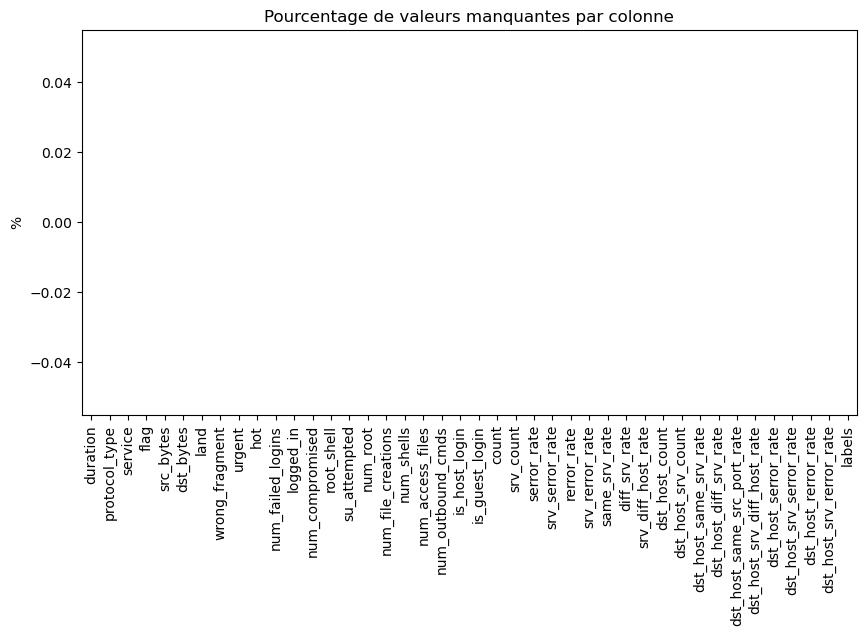

In [24]:
missing = df.isnull().mean().sort_values(ascending=False) * 100

plt.figure(figsize=(10,5))
missing.plot(kind="bar")
plt.title("Pourcentage de valeurs manquantes par colonne")
plt.ylabel("%")
plt.show()

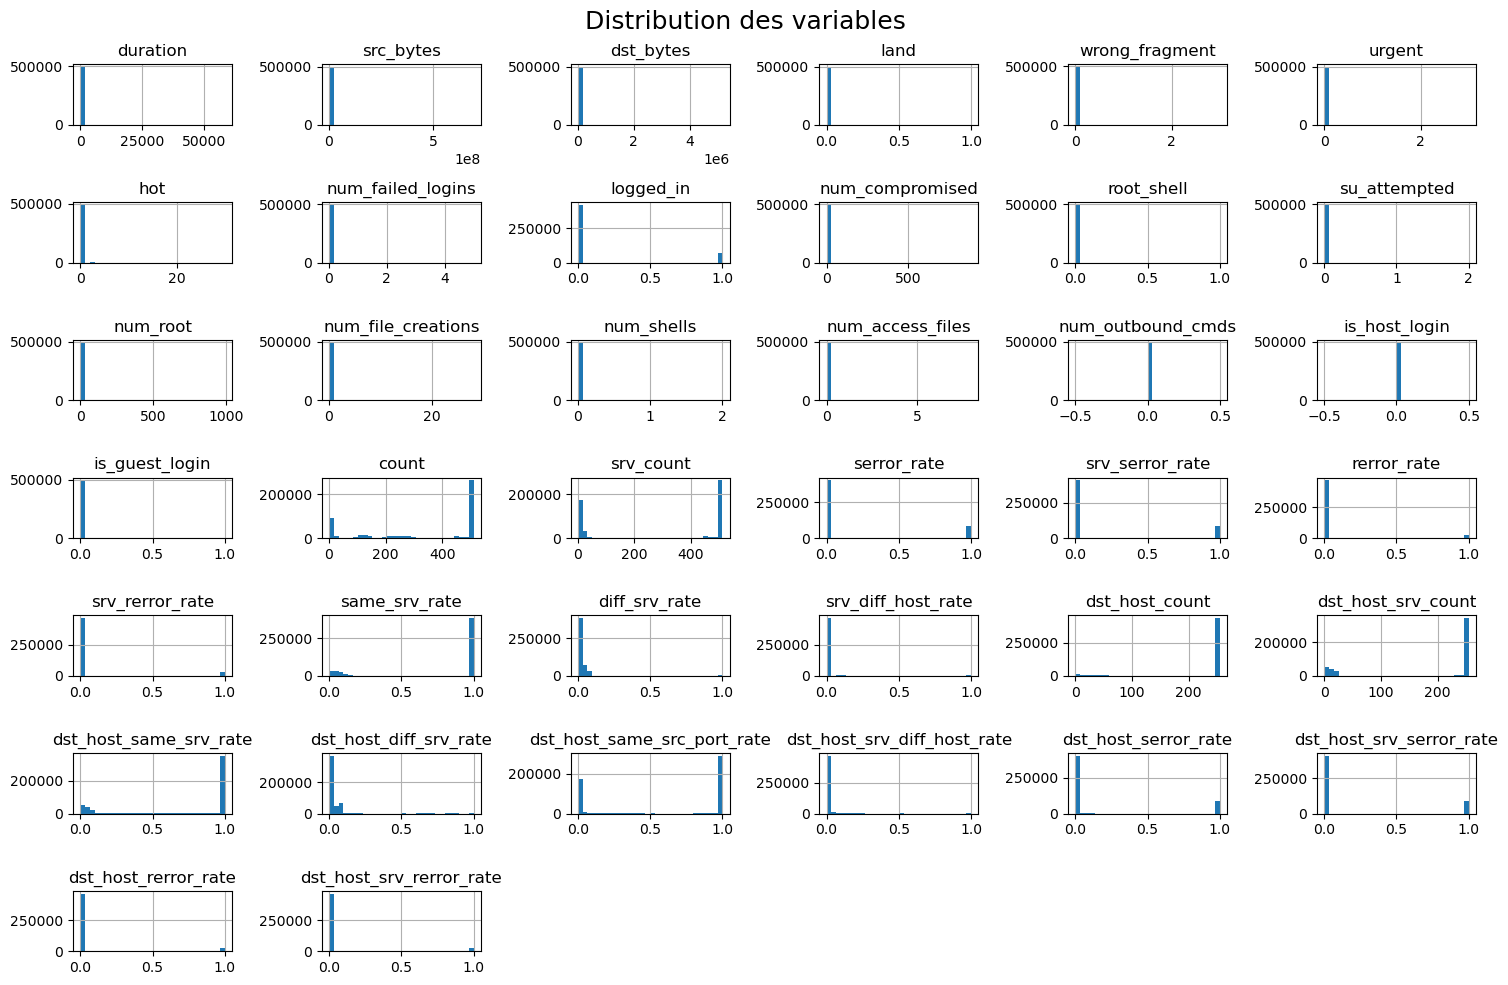

In [32]:
df_numeric = df.select_dtypes(include=[np.number])

df_numeric.hist(figsize=(15,10), bins=30)
plt.suptitle("Distribution des variables", fontsize=18)
plt.tight_layout()

plt.show()

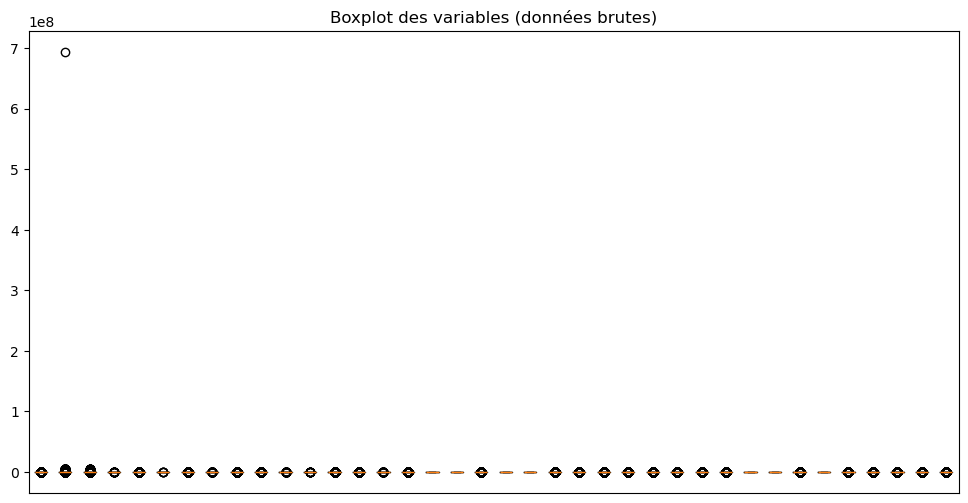

In [26]:
plt.figure(figsize=(12,6))
plt.boxplot(df_numeric.values, showfliers=True)
plt.title("Boxplot des variables (données brutes)")
plt.xticks([])
plt.show()

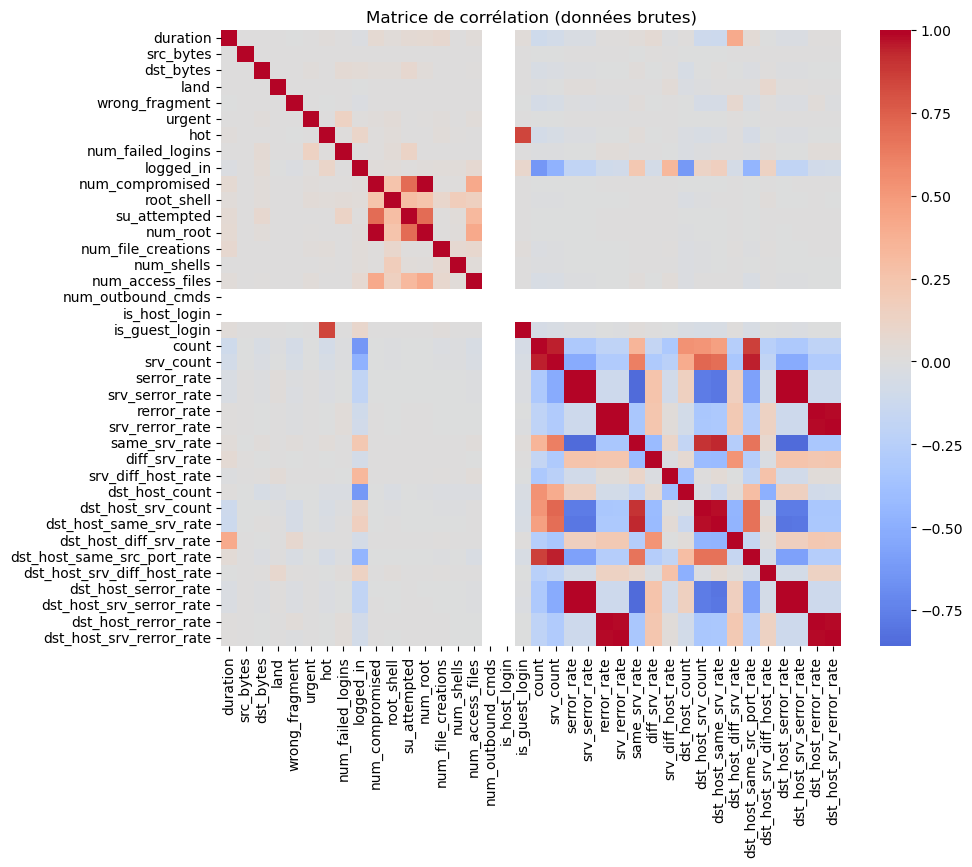

In [27]:
import seaborn as sns

plt.figure(figsize=(10,8))
corr = df_numeric.corr()

sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation (données brutes)")
plt.show()

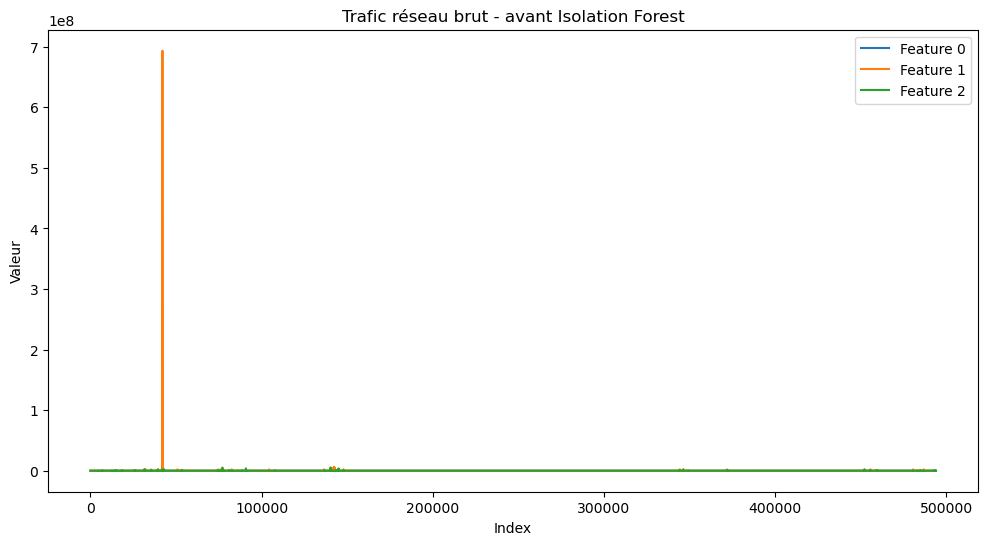

In [19]:
plt.figure(figsize=(12,6))

for i in range(3):  # 3 variables réseau
    plt.plot(df_raw_numeric.iloc[:, i], label=f"Feature {i}")

plt.title("Trafic réseau brut - avant Isolation Forest")
plt.xlabel("Index")
plt.ylabel("Valeur")
plt.legend()
plt.show()

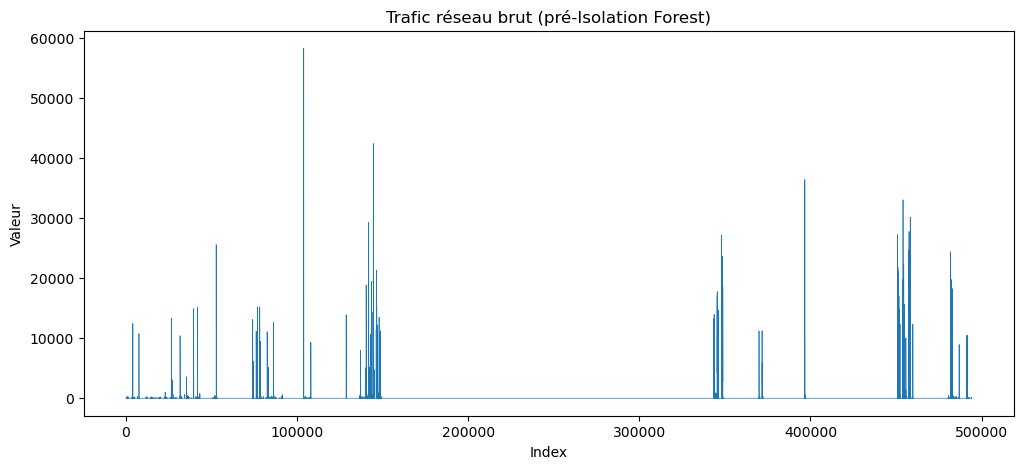

In [20]:
plt.figure(figsize=(12,5))

signal = df_raw_numeric.iloc[:, 0]

plt.plot(signal, linewidth=0.5)

plt.title("Trafic réseau brut (pré-Isolation Forest)")
plt.xlabel("Index")
plt.ylabel("Valeur")
plt.show()